# Classification & non-i.i.d. data

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Oulu-IMEDS/stambo/main?labpath=notebooks%2FClassification_non_iid.ipynb)

V1.0.1: © Aleksei Tiulpin, PhD, 2025

This notebook shows an end-to-end example on how one can compare two models on a test set where data has block-diagonal covariance (i.e. non-i.i.d. samples measured e.g. from the same patient)

## Imports

In [1]:
import stambo
import numpy as np

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold

SEED = 2025

stambo.__version__

'0.1.5'

## Generating synthetic data with block-diagonal covaraince

We use stambo's synthetic dataset generation functionality to generate the dataset in question.

In [2]:
np.random.seed(SEED)
n_subjects = 100
n_data = 300


In [3]:
data, y, subject_ids = stambo.synthetic.generate_non_iid_measurements(
    n_data=n_data,
    n_subjects=n_subjects,
    rho=0.8,             # Subject correlation between classes
    subj_sigma=2.0,       # Strong subject-level effect relative to noise -> more within-subject correlation
    noise_sigma=0.5,
    gamma=0.8,
    mu_cls_1=[2, 2],
    mu_cls_2=[2.1, 2.4],
    overlap=0.4,          # More subjects appear in both classes -> more repeated/correlated measurements
    feat_corr=0.5,       # <--- High correlation between Dim 1 and Dim 2
    seed=2025
)

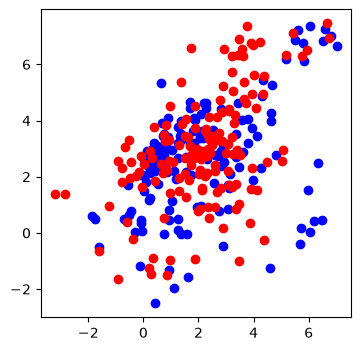

In [4]:
plt.figure(figsize=(4, 4))
plt.plot(data[y == 0, 0], data[y == 0, 1], "bo")
plt.plot(data[y == 1, 0], data[y == 1, 1], "ro")
plt.show()



In [5]:
gss = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
train_idx, test_idx = next(gss.split(data, y, groups=subject_ids))

# Split the data into training and testing sets
X_train, X_test = data[train_idx], data[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = subject_ids[train_idx], subject_ids[test_idx]

# Initialize classifiers
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression()

# Train classifiers
knn.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# Make predictions
knn_predictions = knn.predict_proba(X_test)[:, 1]
logreg_predictions = logreg.predict_proba(X_test)[:, 1]

What we should expect is that on a small test set with correlated, repeated measurements from the same subjects, a naive bootstrap (that treats every row as an independent measurement) can make us overconfident: it can report a statistically significant difference between two models even when the evidence, once we account for the subject-level structure, is not actually strong enough to support that conclusion. Let's look at the naive bootstrap first:

In [6]:
testing_result = stambo.compare_models(y_test, logreg_predictions, knn_predictions, ("ROCAUC", "AP"),seed=SEED, n_bootstrap=1000)
print(stambo.to_latex(testing_result, m1_name="logreg", m2_name="kNN"))

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

% \usepackage{booktabs} <-- do not forget to have this imported. 
\begin{tabular}{lll} \\ 
\toprule 
\textbf{Model} & \textbf{ROCAUC} & \textbf{AP} \\ 
\midrule 
logreg & $0.30$ [$0.21$-$0.41$] & $0.42$ [$0.33$-$0.56$] \\ 
kNN & $0.51$ [$0.40$-$0.62$] & $0.51$ [$0.40$-$0.64$] \\ 
\midrule
Effect size & $0.20$ [$0.04$-$0.36]$ & $0.08$ [$-0.01$-$0.17]$ \\ 
\midrule
$p$-value & $0.01$ & $0.05$ \\ 
\bottomrule
\end{tabular}


We observe a statistically significant result here (both ROC-AUC and AP have a one-sided p-value below 0.05). Let us now correct for clustering by passing the subject `groups` to `compare_models`:

In [7]:
testing_result = stambo.compare_models(y_test, logreg_predictions, knn_predictions, metrics=("ROCAUC", "AP"), groups=groups_test, seed=SEED, n_bootstrap=1000)
print(stambo.to_latex(testing_result, m1_name="LR", m2_name="kNN"))

Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]

% \usepackage{booktabs} <-- do not forget to have this imported. 
\begin{tabular}{lll} \\ 
\toprule 
\textbf{Model} & \textbf{ROCAUC} & \textbf{AP} \\ 
\midrule 
LR & $0.30$ [$0.17$-$0.56$] & $0.42$ [$0.24$-$0.73$] \\ 
kNN & $0.51$ [$0.30$-$0.62$] & $0.51$ [$0.35$-$0.71$] \\ 
\midrule
Effect size & $0.20$ [$-0.19$-$0.41]$ & $0.08$ [$-0.12$-$0.18]$ \\ 
\midrule
$p$-value & $0.20$ & $0.26$ \\ 
\bottomrule
\end{tabular}


**Summary:** According to the naive bootstrap (which ignores the fact that several test rows come from the same subject), the difference between the two models looks statistically significant. Once we take the subject-level structure into account with the clustered (cluster/group) bootstrap, the confidence intervals widen considerably and now include 0, and the p-value is no longer below the usual 0.05 threshold. In other words, the naive bootstrap was overconfident purely because it ignored the non-i.i.d. structure of the data -- this is exactly the failure mode that `stambo`'s `groups` argument is designed to correct.